# Class 3 — Conditional Volatility

GARCH, EGARCH, GARCH-in-Mean, leverage effects, and comparison of conditional volatility measures.

**Teaching note.** This notebook is intended to be run from top to bottom. Reusable data-loading and helper routines are in `course_tools_general.py`.


## Setup


In [20]:
# If needed:
# %pip install yfinance arch scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import course_tools_general as ctg


# Download data for any ticker directly into your target variable
spx = ctg.load_prices(ticker="^GSPC", start="1990-01-01")
spx.head()

print(f"S&P 500 sample: {spx.index.min().date()} to {spx.index.max().date()}")

# These range measures were introduced in Class 2.
# Reuse them here without requiring the Class 2 kernel to remain open.
gk20 = ctg.garman_klass_rolling(spx, window=20).to_numpy()
ok20 = ctg.ok_rolling(spx, window=20).to_numpy()


S&P 500 sample: 1990-01-02 to 2026-08-28


## Conditional Volatility Measures
- From Engle and Bollerslev (1986) we use econometric measures of volatility.

- We estimate a return equation as a function of its own lags and a set of controls:

$y_t = \beta_0 + \sum_{i=1}^{k}\beta_i y_{t-i} + \sum_{j=1}^{m}\gamma_j x_{j,t} + \varepsilon_t$

- The innovation or shock is assumed to have mean zero and a conditional variance that changes over time:

$\varepsilon_t = \sigma_t z_t$

where

$z_t \sim N(0,1)$

or

$z_t \sim t_{\nu}(0,1)$

- The conditional variance is assumed to depend on lagged squared shocks and lagged conditional variances.

- For a GARCH$(p,q)$ model,

$\sigma_t^2 = \omega + \sum_{i=1}^{p}\alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{q}\beta_j \sigma_{t-j}^2$

- In the special case of GARCH$(1,1)$,

$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$

- The parameter $\alpha$ measures the impact of recent shocks on volatility, while $\beta$ measures the persistence of volatility over time.

- The conditional standard deviation is given by

$\sigma_t = \sqrt{\sigma_t^2}$

and provides a model-based estimate of time-varying volatility.

- GARCH is essentially an exponentially weighted moving average (EWMA) of past squared shocks, where older observations receive geometrically declining weights.  So there is no need for smoothing as we did with the Range Volatility measures.

### Maximum Likelihood Estimation of the GARCH Model

- The parameters of the GARCH model are estimated by Maximum Likelihood.  It is not a linear model.  We are not in Kansas anymore, as Dorothy found out in The Wizard of Oz.

- Consider the return equation

$y_t = \beta_0 + \sum_{i=1}^{k}\beta_i y_{t-i} + \sum_{j=1}^{m}\gamma_j x_{j,t} + \varepsilon_t$

with

$\varepsilon_t = \sigma_t z_t$

where

$z_t \sim N(0,1)$

or alternatively a standardized Student-$t$ distribution.

- The conditional variance evolves according to

$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$

- Given a trial set of parameter values, the model recursively computes:

    1. The fitted mean equation
    2. The residuals $\varepsilon_t$
    3. The sequence of conditional variances $\sigma_t^2$

- Under the Normal distribution assumption, the conditional density of each observation is

$f(y_t|\mathcal{F}_{t-1})
=
\frac{1}{\sqrt{2\pi\sigma_t^2}}
\exp\left(
-\frac{\varepsilon_t^2}{2\sigma_t^2}
\right)$

where $\mathcal{F}_{t-1}$ denotes all information available at time $t-1$.

- Assuming conditional independence, the likelihood function is

$L(\theta)
=
\prod_{t=1}^{T}
f(y_t|\mathcal{F}_{t-1})$

where $\theta$ contains all parameters of the model.

- Since products of many probabilities can become numerically very small, we maximize the log-likelihood instead:

$\log L(\theta)
=
\sum_{t=1}^{T}
\log f(y_t|\mathcal{F}_{t-1})$

- For the Normal distribution, the log-likelihood is

$\log L(\theta)
=
-\frac{1}{2}
\sum_{t=1}^{T}
\left[
\log(2\pi)
+
\log(\sigma_t^2)
+
\frac{\varepsilon_t^2}{\sigma_t^2}
\right]$

- Numerical optimization algorithms search over alternative parameter values to find those that maximize the log-likelihood.

- The resulting estimates are called Maximum Likelihood Estimates (MLEs).

- Intuitively, the MLE chooses the parameter values that make the observed sequence of returns most likely to have been generated by the model.

- Once the optimal parameters have been found, the model produces estimates of the conditional variance $\sigma_t^2$ and conditional volatility $\sigma_t$ for every date in the sample.

### Estimation Algorithm

* Numerical optimization algorithms search over alternative parameter values to maximize the log-likelihood function.

* Starting from an initial guess, the algorithm repeatedly updates the parameter values, recomputes the conditional variances, and evaluates the log-likelihood.

* Modern econometric software typically uses gradient-based optimization methods, such as Newton or quasi-Newton methods. These methods use information about the slope and curvature of the log-likelihood function to move efficiently toward the optimum.

* Let the vector of parameters to be estimated be

$$
x =
\begin{bmatrix}
\beta_0 & \beta_1 & \cdots & \gamma_1 & \cdots & \beta & \omega & \varepsilon
\end{bmatrix}'.
$$

* The **Newton method** for maximizing the log-likelihood works as follows.

  1. Choose an initial guess for the parameter vector, $x_0$.

  2. At iteration $k$, evaluate the log-likelihood

  $$
  \mathcal{L}(x_k),
  $$

  its gradient vector

  $$
  g_k = \nabla \mathcal{L}(x_k),
  $$

  and its Hessian matrix

  $$
  H_k = \nabla^2 \mathcal{L}(x_k).
  $$

  3. Use a second-order Taylor approximation to the log-likelihood around the current parameter vector $x_k$:

  $$
  \mathcal{L}(x)
  \approx
  \mathcal{L}(x_k)
  +
  g_k'(x-x_k)
  +
  \frac{1}{2}(x-x_k)'H_k(x-x_k).
  $$

  4. Maximize this quadratic approximation with respect to $x$. The first-order condition is

  $$
  g_k + H_k(x_{k+1}-x_k)=0.
  $$

  Solving for the new parameter vector gives the Newton update:

  $$
  \boxed{
  x_{k+1}
  =
  x_k-H_k^{-1}g_k
  }
  $$

  or, equivalently,

  $$
  x_{k+1}
  =
  x_k-
  \left[\nabla^2\mathcal{L}(x_k)\right]^{-1}
  \nabla\mathcal{L}(x_k).
  $$

* After obtaining $x_{k+1}$, the log-likelihood, gradient, and Hessian are evaluated again at the new parameter values.

* The iterations continue,

$$
x_0 \rightarrow x_1 \rightarrow x_2 \rightarrow \cdots,
$$

until convergence is obtained. Convergence is usually defined by sufficiently small changes in the parameter vector, the log-likelihood, or the gradient.

* **Quasi-Newton methods** follow the same basic idea but do not calculate the full Hessian matrix directly. Instead, they construct an approximation to the Hessian from successive evaluations of the gradient. This can greatly reduce the computational burden when many parameters must be estimated.

* In machine learning, related optimization methods include gradient descent, stochastic gradient descent, and adaptive algorithms such as Adam.

* Regardless of the specific optimization algorithm, the objective is the same: to find the parameter values that make the observed data as likely as possible.

* It is usually easier to maximize the **sum of the log-likelihoods**,

$$
\mathcal{L}(x)
=
\sum_{t=1}^{T}\log f(y_t\mid x),
$$

rather than maximize the product of the individual likelihood contributions,

$$
L(x)
=
\prod_{t=1}^{T}f(y_t\mid x).
$$

Because the logarithm is a monotonically increasing function, both procedures give the same parameter estimates.

* Finally, many numerical optimization programs are written as **minimization** routines. In this case, maximum-likelihood estimation is implemented by minimizing the **negative log-likelihood**:

$$
\boxed{
\min_x \left[-\mathcal{L}(x)\right].
}
$$


### References

* Engle, R. F., & Bollerslev, T. (1986). Modelling the persistence of conditional variances. *Econometric Reviews*, 5(1), 1–50. <br>https://doi.org
* Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007. <br>https://doi.org
* Bollerslev, T., Engle, R. F., & Nelson, D. B. (1994). ARCH models. *Handbook of Econometrics*, 4, 2959–3038. <br>https://doi.org



In [21]:
!pip install arch
import numpy as np
import pandas as pd
from arch import arch_model

# ---------------------------------
# Build y and X
# ---------------------------------

nlags = 5

r = spx['Return'].dropna().to_numpy()

# dependent variable
y = r[nlags:]

# lagged returns


# ---------------------------------
# Day-of-week dummies
# Monday omitted
# ---------------------------------



# combine lags and dummies


# column names
lag_names = [f'Lag{i+1}' for i in range(nlags)]



# ---------------------------------
# ARX(5)-GARCH(1,1)
# ---------------------------------
y = 100 * y

garch_model = arch_model(
    y,
 
    mean='ARX',
    lags=5,          # lags already in X
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_results = garch_model.fit()

print(garch_results.summary())

Iteration:      1,   Func. Count:     11,   Neg. LLF: 2937977637355513.5
Iteration:      2,   Func. Count:     26,   Neg. LLF: 226732191325.07385
Iteration:      3,   Func. Count:     40,   Neg. LLF: 150050055447.84146
Iteration:      4,   Func. Count:     53,   Neg. LLF: 42590106393.86664
Iteration:      5,   Func. Count:     66,   Neg. LLF: 201861.3468664888
Iteration:      6,   Func. Count:     80,   Neg. LLF: 18074.5972840535
Iteration:      7,   Func. Count:     92,   Neg. LLF: 159239.72167116377
Iteration:      8,   Func. Count:    106,   Neg. LLF: 14665.676769477366
Iteration:      9,   Func. Count:    118,   Neg. LLF: 12621.346584848849
Iteration:     10,   Func. Count:    129,   Neg. LLF: 12260.94355378722
Iteration:     11,   Func. Count:    140,   Neg. LLF: 18228.86823542186
Iteration:     12,   Func. Count:    152,   Neg. LLF: 12241.101989392906
Iteration:     13,   Func. Count:    163,   Neg. LLF: 12233.738206083608
Iteration:     14,   Func. Count:    173,   Neg. LLF: 122

In [22]:
# Conditional variance from GARCH
cond_vol = garch_results.conditional_volatility
cond_var = cond_vol ** 2

# Dates aligned with y = r[nlags:]
dates = spx['Return'].dropna().index[nlags:]

# Put into a DataFrame
garch_var_df = pd.DataFrame({
    'Conditional_Variance': cond_var,
    'Conditional_Volatility': cond_vol
}, index=dates)

print(garch_var_df.head())
print(garch_var_df.tail())

            Conditional_Variance  Conditional_Volatility
Date                                                    
1990-01-10                   NaN                     NaN
1990-01-11                   NaN                     NaN
1990-01-12                   NaN                     NaN
1990-01-15                   NaN                     NaN
1990-01-16                   NaN                     NaN
            Conditional_Variance  Conditional_Volatility
Date                                                    
2026-08-24              0.549348                0.741180
2026-08-25              0.516993                0.719022
2026-08-26              0.477834                0.691255
2026-08-27              0.440087                0.663390
2026-08-28              0.446389                0.668124


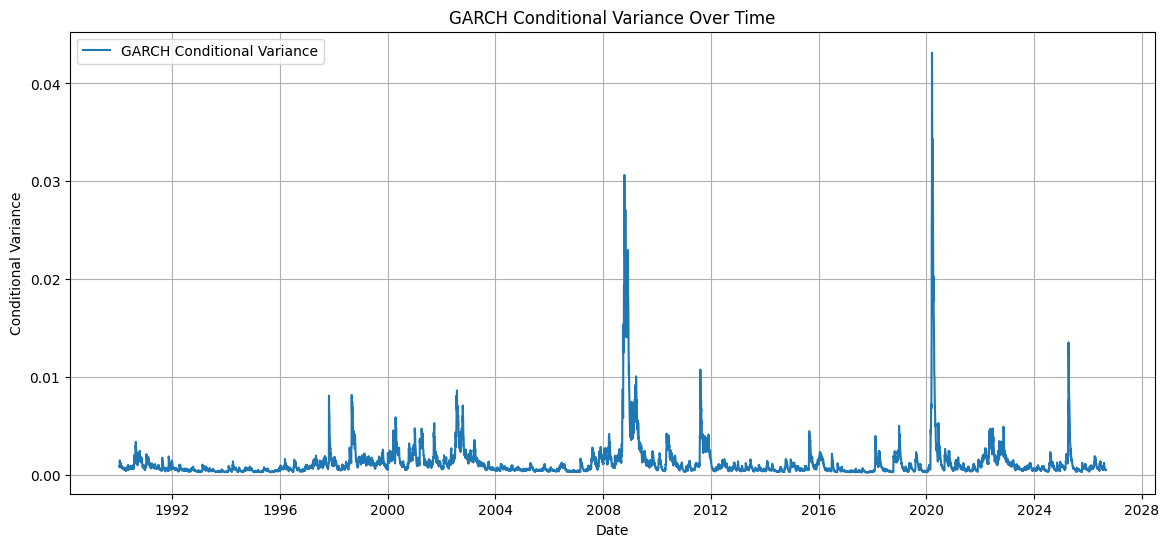

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(
    garch_var_df.index,
    .001 * garch_var_df['Conditional_Variance'],
    label='GARCH Conditional Variance'
)

plt.title('GARCH Conditional Variance Over Time')
plt.xlabel('Date')
plt.ylabel('Conditional Variance')
plt.grid(True)
plt.legend()
plt.show()

In [24]:
# GARCH conditional volatility
garch_vol = pd.Series(
    garch_results.conditional_volatility,
    index=spx['Return'].dropna().index[nlags:]
)

# Put everything together
vol_df = pd.concat([
    pd.Series(gk20, index=spx.index, name='GK'),
    pd.Series(ok20, index=spx.index, name='OK'),
    garch_vol.rename('GARCH')
], axis=1)

print(vol_df.head())
print(vol_df.tail())

            GK  OK  GARCH
Date                     
1990-01-02 NaN NaN    NaN
1990-01-03 NaN NaN    NaN
1990-01-04 NaN NaN    NaN
1990-01-05 NaN NaN    NaN
1990-01-08 NaN NaN    NaN
                  GK        OK     GARCH
Date                                    
2026-08-24  0.005235  0.007403  0.741180
2026-08-25  0.005113  0.007246  0.719022
2026-08-26  0.004658  0.006545  0.691255
2026-08-27  0.004549  0.006386  0.663390
2026-08-28  0.004033  0.005789  0.668124


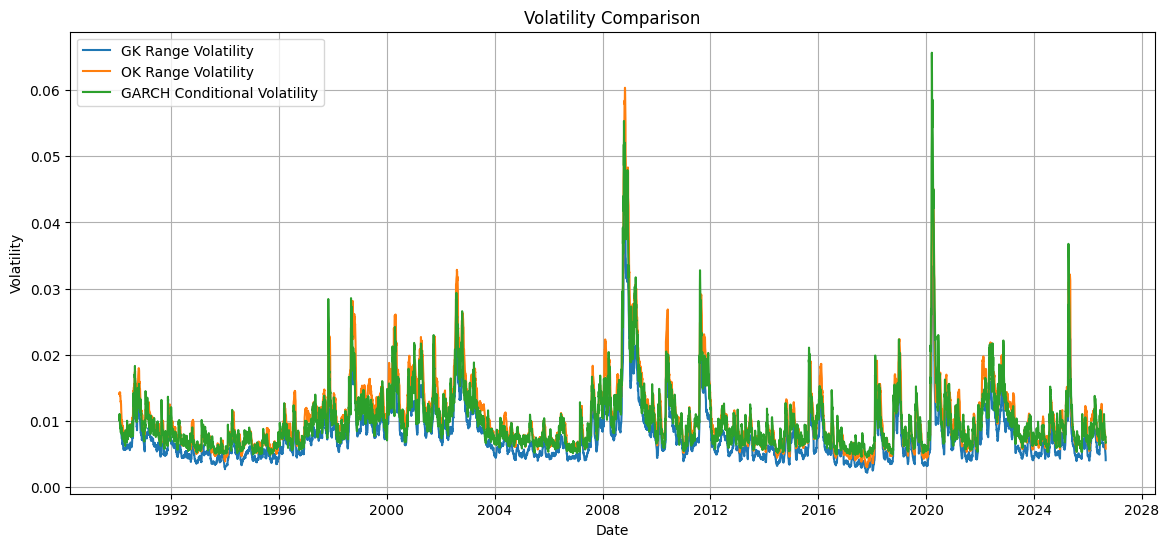

In [6]:
vol_df = vol_df.dropna()

plt.figure(figsize=(14,6))

plt.plot(vol_df.index, vol_df['GK'], label='GK Range Volatility')
plt.plot(vol_df.index, vol_df['OK'], label='OK Range Volatility')
plt.plot(vol_df.index, .01* vol_df['GARCH'], label='GARCH Conditional Volatility')

plt.title('Volatility Comparison')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

## Exponential GARCH (EGARCH) with Leverage Effects

- One of the drawbacks of the standard GARCH process is that positive and negative shocks to returns have the same effect on variance or uncertainty.
- Is this realistic? Would uncertainty increase more when the shocks or surprises are negative?
- Financial markets often exhibit an **asymmetric response** to news. Bad news tends to increase volatility more than good news of the same magnitude.
- This phenomenon is known as the **leverage effect**. When stock prices fall, firms become more highly leveraged, increasing financial risk and future uncertainty.
- To capture this asymmetry, Nelson (1991) proposed the **Exponential GARCH (EGARCH)** model.

### Standard GARCH(1,1)

Recall that the GARCH(1,1) model is

$$
y_t = X_t\beta + \varepsilon_t
$$

where

$$
\varepsilon_t = \sigma_t z_t,
$$

and

$$
z_t \sim N(0,1)
$$

or alternatively a Student-$t$ distribution.

The conditional variance evolves according to

$$
\sigma_t^2
=
\omega
+
\alpha \varepsilon_{t-1}^2
+
\beta \sigma_{t-1}^2.
$$

Since the shock enters as $\varepsilon_{t-1}^2$, positive and negative shocks have identical effects on volatility.

### EGARCH(1,1)

The EGARCH model specifies the logarithm of variance rather than variance itself:

$$
\log(\sigma_t^2)
=
\omega
+
\beta \log(\sigma_{t-1}^2)
+
\alpha
\left(
\frac{|\varepsilon_{t-1}|}{\sigma_{t-1}}
-
E\left[\frac{|\varepsilon_{t-1}|}{\sigma_{t-1}}\right]
\right)
+
\gamma
\frac{\varepsilon_{t-1}}{\sigma_{t-1}}.
$$

Define the standardized shock as

$$
z_{t-1}
=
\frac{\varepsilon_{t-1}}{\sigma_{t-1}}.
$$

An equivalent representation is

$$
\log(\sigma_t^2)
=
\omega
+
\beta \log(\sigma_{t-1}^2)
+
\alpha(|z_{t-1}|-E|z_{t-1}|)
+
\gamma z_{t-1}.
$$

### Interpretation of the Parameters

#### Persistence

The parameter

$$
\beta
$$

measures the persistence of volatility.

- Large values imply that periods of high volatility tend to be followed by high volatility.
- Volatility clustering remains an important feature of the model.

#### Magnitude Effect

The parameter

$$
\alpha
$$

measures the effect of the size of the shock.

- Large positive or negative surprises increase uncertainty.
- The effect depends on the absolute value of the standardized shock.

#### Asymmetry or Leverage Effect

The parameter

$$
\gamma
$$

captures the asymmetry between positive and negative shocks.

If

$$
\gamma < 0,
$$

then

- Negative shocks increase volatility more than positive shocks.
- Bad news has a larger effect on uncertainty than good news.

This is the pattern commonly observed in equity markets.

### Why the Logarithm of Variance?

An attractive feature of EGARCH is that variance is automatically positive.

Because

$$
\sigma_t^2
=
\exp\left(
\log(\sigma_t^2)
\right),
$$

the variance can never become negative.

In contrast, standard GARCH requires parameter restrictions such as

$$
\omega > 0,
\qquad
\alpha \ge 0,
\qquad
\beta \ge 0.
$$

EGARCH does not require these non-negativity constraints.

### Forecasting Volatility

Once the parameters have been estimated by maximum likelihood, forecasts are generated recursively:

$$
\widehat{\log(\sigma_{t+1}^2)}
=
\hat{\omega}
+
\hat{\beta}\log(\sigma_t^2)
+
\hat{\alpha}
(|z_t|-E|z_t|)
+
\hat{\gamma}z_t.
$$

The forecast variance is then

$$
\hat{\sigma}_{t+1}^2
=
\exp
\left(
\widehat{\log(\sigma_{t+1}^2)}
\right).
$$

The annualized volatility forecast is

$$
\hat{\sigma}_{t+1,\text{annual}}
=
\sqrt{250}\,
\hat{\sigma}_{t+1}.
$$

### Why Use EGARCH?

EGARCH is particularly useful for financial returns because it captures:

1. **Volatility clustering**
   - High-volatility periods tend to follow high-volatility periods.

2. **Fat tails**
   - Through Student-$t$ innovations.

3. **Leverage effects**
   - Negative shocks increase volatility more than positive shocks.

4. **Positive variance**
   - Guaranteed through the logarithmic specification.

For these reasons EGARCH is widely used in empirical finance, risk management, option pricing, and forecasting market volatility.

### References

- Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity*. Journal of Econometrics, 31, 307--327.
- Engle, R. F. (1982). *Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of United Kingdom Inflation*. Econometrica, 50, 987--1007.
- Nelson, D. B. (1991). *Conditional Heteroskedasticity in Asset Returns: A New Approach*. Econometrica, 59, 347--370.
- Tsay, R. S. (2010). *Analysis of Financial Time Series*, 3rd Edition. Wiley.
- McNeil, A., Frey, R., and Embrechts, P. (2015). *Quantitative Risk Management*. Princeton University Press.

### Key Insight

A useful way to think about the difference between the two models is:

- **GARCH:** volatility responds symmetrically to positive and negative shocks.
- **EGARCH:** volatility responds asymmetrically, allowing bad news to have a larger impact on uncertainty than good news.
- This asymmetry is one of the most important empirical regularities in financial markets and is a major reason why EGARCH models are widely used in practice.


In [7]:
from arch import arch_model

# X_df should contain only weekday dummies
# lags handled by lags=5


egarch_lev_model = arch_model(
    y,
 
    mean='ARX',
    lags=5,
    vol='EGARCH',
    p=1,
    o=1,
    q=1,
    dist='t',
    rescale=False
)

egarch_lev_results = egarch_lev_model.fit(
    disp='on',
    options={
        'maxiter': 5000,
        'ftol': 1e-8
    }
)

print(egarch_lev_results.summary())

Iteration:      1,   Func. Count:     13,   Neg. LLF: 107277.38875943041
Iteration:      2,   Func. Count:     32,   Neg. LLF: 320318.1323105259
Iteration:      3,   Func. Count:     49,   Neg. LLF: 285505.8677791706
Iteration:      4,   Func. Count:     65,   Neg. LLF: 293697.555396275
Iteration:      5,   Func. Count:     81,   Neg. LLF: 557771.8387623534
Iteration:      6,   Func. Count:     97,   Neg. LLF: 250134.0412740131
Iteration:      7,   Func. Count:    113,   Neg. LLF: 38254.00962872277
Iteration:      8,   Func. Count:    129,   Neg. LLF: 20892.15045539508
Iteration:      9,   Func. Count:    145,   Neg. LLF: 14543.232076311459
Iteration:     10,   Func. Count:    160,   Neg. LLF: 14590.585401256703
Iteration:     11,   Func. Count:    174,   Neg. LLF: 11963.01040014836
Iteration:     12,   Func. Count:    188,   Neg. LLF: 6991210.388859901
Iteration:     13,   Func. Count:    204,   Neg. LLF: 11856.2595157361
Iteration:     14,   Func. Count:    216,   Neg. LLF: 11856.257

In [8]:
egarch_lev_results = egarch_lev_model.fit()

Iteration:      1,   Func. Count:     13,   Neg. LLF: 107277.38875943041
Iteration:      2,   Func. Count:     32,   Neg. LLF: 320318.1323105259
Iteration:      3,   Func. Count:     49,   Neg. LLF: 285505.8677791706
Iteration:      4,   Func. Count:     65,   Neg. LLF: 293697.555396275
Iteration:      5,   Func. Count:     81,   Neg. LLF: 557771.8387623534
Iteration:      6,   Func. Count:     97,   Neg. LLF: 250134.0412740131
Iteration:      7,   Func. Count:    113,   Neg. LLF: 38254.00962872277
Iteration:      8,   Func. Count:    129,   Neg. LLF: 20892.15045539508
Iteration:      9,   Func. Count:    145,   Neg. LLF: 14543.232076311459
Iteration:     10,   Func. Count:    160,   Neg. LLF: 14590.585401256703
Iteration:     11,   Func. Count:    174,   Neg. LLF: 11963.01040014836
Iteration:     12,   Func. Count:    188,   Neg. LLF: 6991210.388859901
Iteration:     13,   Func. Count:    204,   Neg. LLF: 11856.2595157361
Iteration:     14,   Func. Count:    216,   Neg. LLF: 11856.257

In [9]:
egarch_df = pd.DataFrame({
    'Volatility': egarch_lev_results.conditional_volatility,
    'Variance': egarch_lev_results.conditional_volatility**2
},
index=spx['Return'].dropna().index[nlags:])



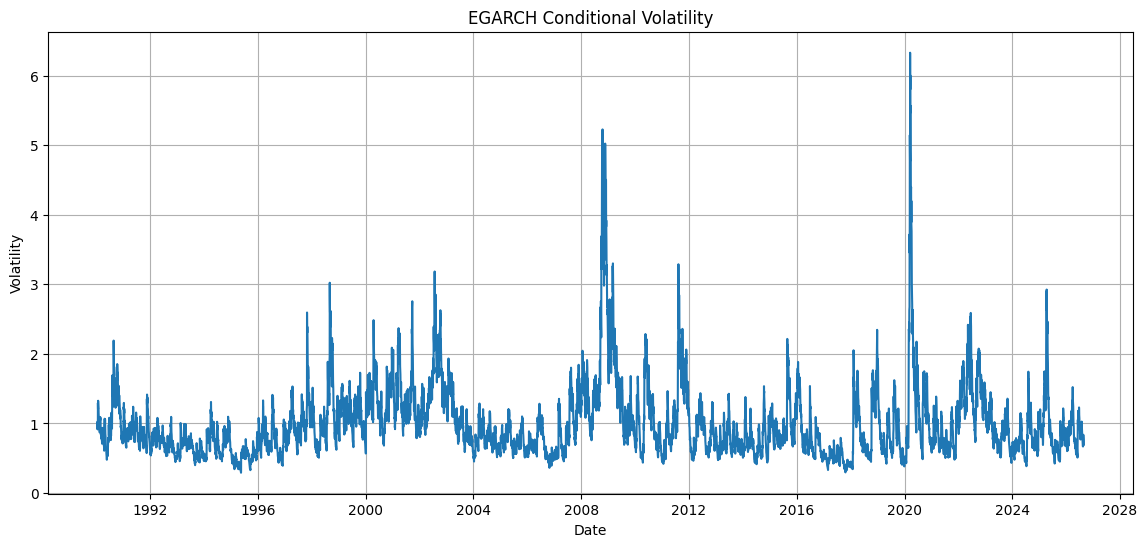

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    egarch_df.index,
    egarch_df['Volatility']
)

plt.title('EGARCH Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)

plt.show()

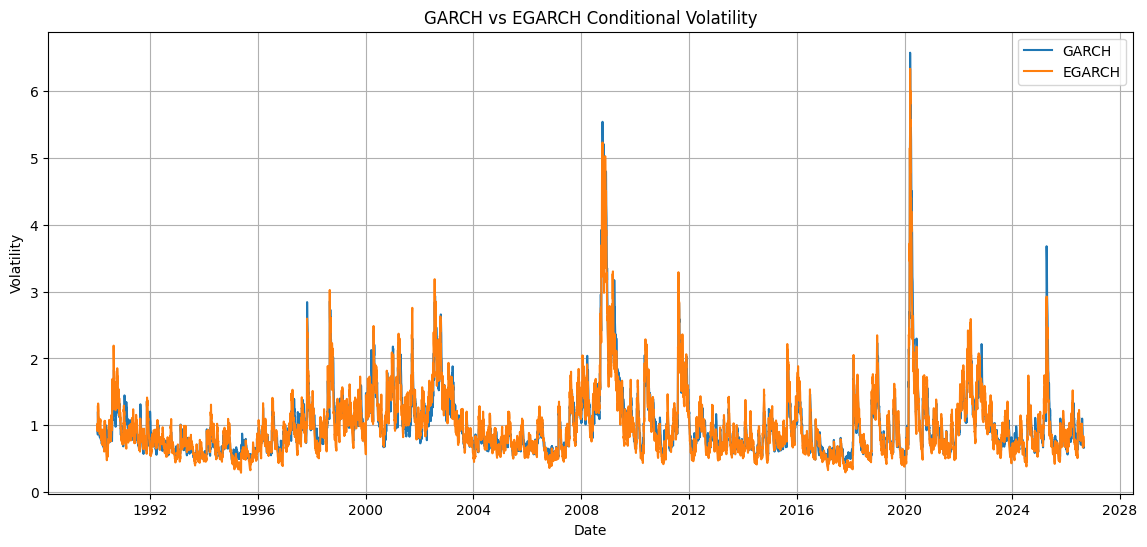

In [11]:
egarch_vol = pd.Series(
    egarch_lev_results.conditional_volatility,
    index=spx['Return'].dropna().index[nlags:],
    name='EGARCH'
)
compare_df = pd.concat([
    garch_vol.rename('GARCH'),
    egarch_vol.rename('EGARCH')
], axis=1).dropna()

plt.figure(figsize=(14,6))

plt.plot(compare_df.index, compare_df['GARCH'], label='GARCH')
plt.plot(compare_df.index, compare_df['EGARCH'], label='EGARCH')

plt.title('GARCH vs EGARCH Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

The GARCH and EGARCH conditional volatility estimates are highly correlated, suggesting that the leverage effect changes the dynamics only modestly in this sample. The Garman-Klass and open-close range-based estimates are also very close, reflecting their common use of intraday price-range information. The model-based and range-based volatility measures capture similar episodes of market stress, though their levels may differ.

## GARCH-in-Mean: Linking Expected Return and Conditional Volatility

- Standard GARCH models focus on forecasting volatility or uncertainty.
- However, financial theory suggests that investors require compensation for bearing risk.
- If risk varies over time, expected returns should vary over time as well.
- The GARCH-in-Mean (GARCH-M) model incorporates this idea directly by allowing conditional volatility to enter the mean return equation.
- The model provides an empirical framework for testing the risk-return tradeoff implied by modern asset-pricing theory.

### The Mean Equation

Suppose returns are given by

$$
r_t
=
\mu
+
\lambda h_t
+
\varepsilon_t,
$$

where

- $r_t$ is the asset return,
- $\mu$ is the constant component of expected return,
- $h_t$ is the conditional variance,
- $\lambda$ measures the effect of risk on expected return,
- $\varepsilon_t$ is the innovation or shock.

The innovation is given by

$$
\varepsilon_t
=
\sqrt{h_t}z_t,
$$

where

$$
z_t \sim N(0,1)
$$

or alternatively follows a Student-$t$ distribution.

The conditional expectation of returns is therefore

$$
E_{t-1}(r_t)
=
\mu
+
\lambda h_t.
$$

### Using Volatility Instead of Variance

Some researchers prefer to use conditional volatility rather than conditional variance:

$$
r_t
=
\mu
+
\lambda \sigma_t
+
\varepsilon_t,
$$

where

$$
\sigma_t = \sqrt{h_t}.
$$

This specification is often easier to interpret because volatility is measured in the same units as returns.

### GARCH(1,1) Variance Equation

The conditional variance evolves according to

$$
h_t
=
\omega
+
\alpha \varepsilon_{t-1}^2
+
\beta h_{t-1}.
$$

where

- $\omega$ is the long-run variance component,
- $\alpha$ measures the impact of recent shocks,
- $\beta$ measures the persistence of volatility.

The restrictions

$$
\omega > 0,
\qquad
\alpha \ge 0,
\qquad
\beta \ge 0
$$

ensure positive conditional variance.

### Lagged Volatility Specification

A common alternative is to use lagged variance in the mean equation:

$$
r_t
=
\mu
+
\lambda h_{t-1}
+
\varepsilon_t.
$$

or

$$
r_t
=
\mu
+
\lambda \sigma_{t-1}
+
\varepsilon_t.
$$

This specification avoids simultaneity and makes the interpretation more natural:

- Today's expected return depends on yesterday's forecast of risk.

The conditional expectation becomes

$$
E_{t-1}(r_t)
=
\mu
+
\lambda h_{t-1}.
$$

### Interpretation of the Risk Premium Parameter

The key parameter is

$$
\lambda.
$$

#### Positive Risk-Return Tradeoff

If

$$
\lambda > 0,
$$

then higher volatility predicts higher expected returns.

This result is consistent with standard asset-pricing theory:

- Investors require a higher expected return when risk increases.

#### No Risk-Return Tradeoff

If

$$
\lambda = 0,
$$

then conditional volatility does not affect expected returns.

In this case the model reduces to a standard GARCH specification.

#### Negative Relationship

If

$$
\lambda < 0,
$$

then higher volatility predicts lower returns.

Although this result is contrary to simple theoretical models, it is sometimes observed in short-horizon stock market data during periods of financial stress.

### Maximum Likelihood Estimation

The parameters

$$
\Theta
=
(\mu,\lambda,\omega,\alpha,\beta)
$$

are estimated by maximizing the log-likelihood function.

Assuming normal innovations,

$$
L(\Theta)
=
\prod_{t=1}^{T}
\frac{1}
{\sqrt{2\pi h_t}}
\exp
\left(
-\frac{\varepsilon_t^2}
{2h_t}
\right).
$$

The corresponding log-likelihood is

$$
\ell(\Theta)
=
-\frac{1}{2}
\sum_{t=1}^{T}
\left[
\log(2\pi)
+
\log(h_t)
+
\frac{\varepsilon_t^2}{h_t}
\right].
$$

Numerical optimization methods are then used to obtain the parameter estimates.

### Forecasting

After estimation, expected returns can be forecast using

$$
\hat r_{t+1}
=
\hat\mu
+
\hat\lambda
\hat h_t.
$$

or

$$
\hat r_{t+1}
=
\hat\mu
+
\hat\lambda
\hat\sigma_t.
$$

The volatility forecast is generated recursively from

$$
\hat h_{t+1}
=
\hat\omega
+
\hat\alpha \hat\varepsilon_t^2
+
\hat\beta \hat h_t.
$$

Thus the GARCH-in-Mean model jointly forecasts

1. Expected returns,
2. Conditional volatility,
3. Time-varying risk premia.

### Why Use GARCH-in-Mean?

The model allows researchers to answer an important question:

> Does higher risk lead to higher expected returns?

The GARCH-M framework combines:

- Forecasting of expected returns,
- Forecasting of volatility,
- Estimation of the time-varying risk premium.

For this reason it has been widely used in studies of equity markets, exchange rates, interest rates, and commodity prices.

### References

- Engle, R. F., Lilien, D. M., and Robins, R. P. (1987). *Estimating Time Varying Risk Premia in the Term Structure: The ARCH-M Model*. Econometrica, 55, 391--407.
- Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity*. Journal of Econometrics, 31, 307--327.
- Engle, R. F. (1982). *Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of United Kingdom Inflation*. Econometrica, 50, 987--1007.
- Tsay, R. S. (2010). *Analysis of Financial Time Series*, 3rd Edition. Wiley.
- Francq, C., and Zakoian, J.-M. (2019). *GARCH Models: Structure, Statistical Inference and Financial Applications*. Wiley.

### Key Insight

Standard GARCH models estimate conditional volatility.  
GARCH-in-Mean goes one step further by allowing conditional volatility to influence expected returns directly.

In this sense, GARCH-M provides a bridge between volatility modeling and asset-pricing theory by estimating both risk and the compensation investors receive for bearing that risk.

In [12]:
from arch.univariate import ARCHInMean, GARCH, StudentsT

# X_df should contain only weekday dummies


garch_m_model = ARCHInMean(
    y,
 
    lags=5,
    volatility=GARCH(p=1, q=1),
    distribution=StudentsT(),
    rescale=False
)

garch_m_results = garch_m_model.fit(
    disp="on",
    options={
        "maxiter": 5000,
        "ftol": 1e-8
    }
)

print(garch_m_results.summary())

Iteration:      1,   Func. Count:     13,   Neg. LLF: 241166.82385652643
Iteration:      2,   Func. Count:     31,   Neg. LLF: 208190.5650726596
Iteration:      3,   Func. Count:     48,   Neg. LLF: 269038.3206995742
Iteration:      4,   Func. Count:     63,   Neg. LLF: 287644.2494104282
Iteration:      5,   Func. Count:     79,   Neg. LLF: 166627.88054785196
Iteration:      6,   Func. Count:     94,   Neg. LLF: 186785.4783489977
Iteration:      7,   Func. Count:    109,   Neg. LLF: 60913.63744709887
Iteration:      8,   Func. Count:    125,   Neg. LLF: 24850.79018756045
Iteration:      9,   Func. Count:    139,   Neg. LLF: 43943.40052719053
Iteration:     10,   Func. Count:    154,   Neg. LLF: 21464.763683356177
Iteration:     11,   Func. Count:    167,   Neg. LLF: 12051.14591015893
Iteration:     12,   Func. Count:    180,   Neg. LLF: 21125.45091320813
Iteration:     13,   Func. Count:    193,   Neg. LLF: 12000.259086161695
Iteration:     14,   Func. Count:    206,   Neg. LLF: 12014.

## GARCH in MEAN Inerpretation
- The GARCH-in-Mean coefficient, $\kappa$, is positive and statistically significant. 
- This suggests that periods of higher conditional volatility are associated with higher expected returns. 
- Thus, the model provides evidence for a positive risk-return tradeoff in the S&P 500 returns.

= The estimated GARCH parameters also show strong volatility persistence. 
= The sum $\alpha_1 + \beta_1$ is approximately:

$$
0.0937 + 0.9024 = 0.9961
$$

- This indicates that shocks to volatility decay slowly over time.

## GJR-GARCH-in-Mean Model with Leverage Effects

Glosten, Jagannathan, and Runkle (1993) proposed an extension of the GARCH model that allows positive and negative shocks to have different effects on future volatility. This model is commonly called the **GJR-GARCH** model or **Threshold GARCH** model.

We can combine this idea with a **GARCH-in-Mean** specification. The GARCH-in-Mean term allows expected returns to depend directly on conditional volatility or risk.

The mean equation is

$$
r_t =
\mu
+
\sum_{i=1}^{5} \phi_i r_{t-i}
+
X_t'\beta
+
\kappa h_t
+
\varepsilon_t
$$

where:

- $r_t$ is the return,
- $r_{t-i}$ are lagged returns,
- $X_t$ contains control variables such as weekday dummy variables,
- $h_t$ is the conditional variance,
- $\kappa$ measures the GARCH-in-Mean effect,
- $\varepsilon_t$ is the return innovation.

The shock is written as

$$
\varepsilon_t = \sqrt{h_t}z_t,
\qquad z_t \sim t_\nu
$$

where $z_t$ follows a Student's $t$ distribution.

The conditional variance equation is

$$
h_t =
\omega
+
\alpha \varepsilon_{t-1}^2
+
\gamma \varepsilon_{t-1}^2 I(\varepsilon_{t-1}<0)
+
\beta h_{t-1}
$$

where:

- $h_t$ is the conditional variance,
- $\omega$ is the constant term in the variance equation,
- $\alpha$ measures the effect of positive shocks,
- $\gamma$ measures the additional effect of negative shocks,
- $I(\varepsilon_{t-1}<0)$ equals 1 when the previous shock is negative and 0 otherwise,
- $\beta$ measures volatility persistence.

The coefficient $\kappa$ captures the risk-return tradeoff. If $\kappa > 0$, then higher conditional volatility is associated with higher expected returns.

The coefficient $\gamma$ captures the leverage effect. If $\gamma > 0$, then negative shocks increase volatility more than positive shocks of the same size.

For a positive shock,

$$
h_t =
\omega
+
\alpha \varepsilon_{t-1}^2
+
\beta h_{t-1}
$$

For a negative shock,

$$
h_t =
\omega
+
(\alpha+\gamma)\varepsilon_{t-1}^2
+
\beta h_{t-1}
$$

Thus, in the GJR-GARCH model, a positive value of $\gamma$ is evidence of a leverage effect.

In our S&P 500 estimation, both effects are present. The GARCH-in-Mean coefficient $\kappa$ is positive and statistically significant, suggesting a positive relationship between conditional risk and expected returns. The leverage coefficient $\gamma$ is also positive and statistically significant, suggesting that negative shocks raise future volatility more than positive shocks.

### Reference

Glosten, L. R., Jagannathan, R., and Runkle, D. E. (1993). *On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks*. Journal of Finance, 48(5), 1779–1801.




In [13]:
volatility=GARCH(p=1, o=1, q=1)

In [14]:
from arch.univariate import ARCHInMean, GARCH, StudentsT



garch_m_lev_model = ARCHInMean(
    y,
  
    lags=5,
    volatility=GARCH(p=1, o=1, q=1),   # GJR-GARCH / threshold effect
    distribution=StudentsT(),
    rescale=False
)

garch_m_lev_results = garch_m_lev_model.fit(
    disp="on",
    options={
        "maxiter": 5000,
        "ftol": 1e-8
    }
)

print(garch_m_lev_results.summary())

Iteration:      1,   Func. Count:     14,   Neg. LLF: 418037.50147327594
Iteration:      2,   Func. Count:     33,   Neg. LLF: 322028.965926724
Iteration:      3,   Func. Count:     51,   Neg. LLF: 276846.68712661986
Iteration:      4,   Func. Count:     67,   Neg. LLF: 283592.78124502196
Iteration:      5,   Func. Count:     84,   Neg. LLF: 219996.50413729768
Iteration:      6,   Func. Count:    100,   Neg. LLF: 475216.54431089293
Iteration:      7,   Func. Count:    116,   Neg. LLF: 133778.19434317143
Iteration:      8,   Func. Count:    131,   Neg. LLF: 131552.4045483162
Iteration:      9,   Func. Count:    145,   Neg. LLF: 124073.81464298903
Iteration:     10,   Func. Count:    160,   Neg. LLF: 5867286.361764604
Iteration:     11,   Func. Count:    176,   Neg. LLF: 395399.46176194784
Iteration:     12,   Func. Count:    190,   Neg. LLF: 12365.318595814673
Iteration:     13,   Func. Count:    205,   Neg. LLF: 11960.49660392175
Iteration:     14,   Func. Count:    219,   Neg. LLF: 49

## Interpretation of the GJR-GARCH-in-Mean Results

The estimated GJR-GARCH-in-Mean model provides evidence of short-run return persistence, a positive risk-return tradeoff, and significant asymmetric volatility dynamics in S&P 500 returns.

### Mean Equation

The first lag of returns is positive and highly significant, with an estimated coefficient of

$$
\phi_1 = 0.0660,
$$

indicating modest short-run momentum in daily returns. Positive returns tend to be followed by slightly positive returns on the next trading day. The remaining lag coefficients are statistically insignificant, suggesting that most of the predictive information is contained in the first lag.

The weekday dummy variables indicate systematic calendar effects in returns. Three of the weekday coefficients are negative and statistically significant, implying lower average returns on those trading days relative to the omitted benchmark day.

Most importantly, the GARCH-in-Mean coefficient is

$$
\kappa = 0.0422,
$$

with a p-value of

$$
p = 0.034.
$$

Since the coefficient is positive and statistically significant, periods of higher conditional volatility are associated with higher expected returns. This finding supports the existence of a positive risk-return tradeoff, whereby investors require additional compensation for bearing greater market risk.

### Volatility Equation

The estimated volatility process exhibits substantial persistence. The coefficient on lagged conditional variance is

$$
\beta = 0.9021,
$$

indicating that volatility shocks decay slowly over time. Periods of elevated uncertainty therefore tend to persist.

The ARCH coefficient is

$$
\alpha = 0.0259,
$$

which measures the immediate impact of new information on volatility. Although statistically significant, its magnitude is relatively small compared with the persistence parameter.

The leverage coefficient is

$$
\gamma = 0.1234,
$$

and is highly significant statistically. This provides strong evidence of asymmetric volatility effects.

For positive shocks, the impact on volatility is

$$
\alpha = 0.0259.
$$

For negative shocks, the impact becomes

$$
\alpha + \gamma
=
0.0259 + 0.1234
=
0.1493.
$$

Thus, negative shocks have approximately

$$
\frac{0.1493}{0.0259}
=
5.76
$$

times the effect on future volatility as positive shocks of equal magnitude. This is a classic leverage effect commonly observed in equity markets.

### Volatility Persistence

A useful measure of volatility persistence is

$$
\alpha + \beta
=
0.0259 + 0.9021
=
0.9280.
$$

Since

$$
\alpha + \beta < 1,
$$

the conditional variance process is stationary. However, because the value is close to one, volatility shocks dissipate only gradually.

For the GJR-GARCH model, the persistence measure is often adjusted to account for asymmetry:

$$
\alpha + \beta + \frac{\gamma}{2}
=
0.0259 + 0.9021 + \frac{0.1234}{2}
=
0.9897.
$$

This value is extremely close to one, indicating very persistent volatility dynamics in the S&P 500.

### Distributional Properties

The estimated Student's t degrees-of-freedom parameter is

$$
\nu = 7.09.
$$

Since the estimated value is relatively small, the return distribution possesses heavier tails than the normal distribution. Large positive and negative return realizations occur more frequently than predicted by a Gaussian model.

### Overall Assessment

The GJR-GARCH-in-Mean model reveals three important characteristics of S&P 500 returns:

1. A positive and statistically significant risk-return relationship:

   $$
   \kappa > 0.
   $$

2. Strong volatility persistence:

   $$
   \alpha + \beta + \frac{\gamma}{2}
   \approx
   0.99.
   $$

3. A pronounced leverage effect:

   $$
   \gamma > 0.
   $$

These results suggest that investors respond not only to the overall level of market risk but also to the asymmetric nature of that risk. Negative shocks generate substantially larger increases in uncertainty than positive shocks, while higher volatility is associated with higher expected returns.

### Comparison with the Symmetric GARCH-in-Mean Model

In the symmetric GARCH-in-Mean specification, the estimated risk-premium coefficient was approximately

$$
\kappa = 0.0706.
$$

After introducing the leverage effect, the estimate falls to

$$
\kappa = 0.0422.
$$

This decline suggests that part of the risk premium measured in the symmetric model was actually capturing the asymmetric response of volatility to negative shocks. The GJR-GARCH-in-Mean model therefore provides a richer and more realistic representation of financial market risk.

### Reference

Glosten, L. R., Jagannathan, R., and Runkle, D. E. (1993). *On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks*. *Journal of Finance*, 48(5), 1779–1801.

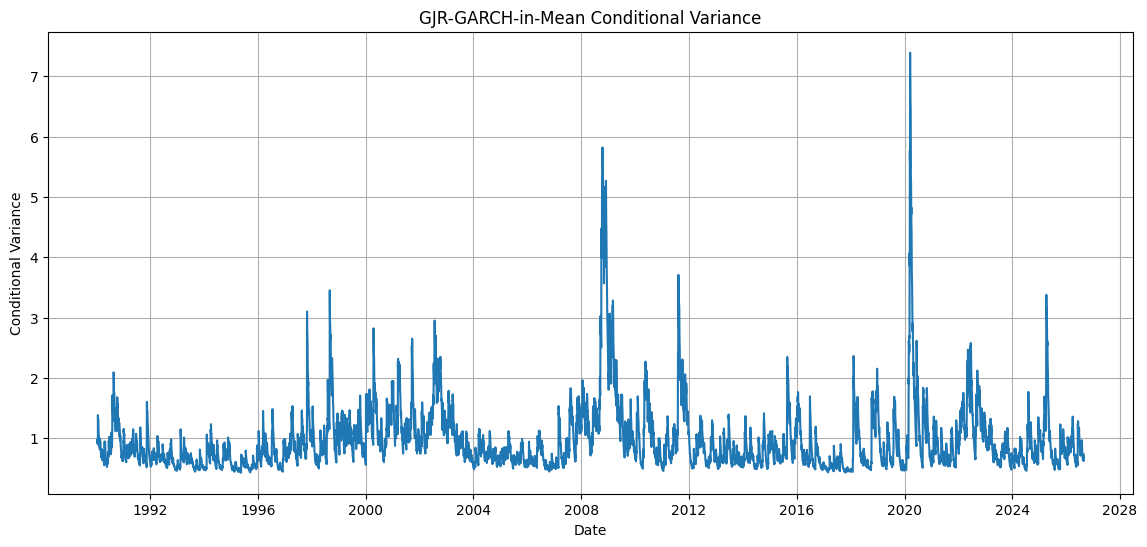

In [15]:
# Conditional volatility and variance
cond_vol = garch_m_lev_results.conditional_volatility
cond_var = cond_vol**2

# Match dates to observations used in estimation
dates = spx.index[-len(cond_var):]

cond_var = pd.Series(
    cond_vol,
    index=dates,
    name="Conditional Variance"
)

plt.figure(figsize=(14,6))
plt.plot(cond_var)
plt.title("GJR-GARCH-in-Mean Conditional Variance")
plt.xlabel("Date")
plt.ylabel("Conditional Variance")
plt.grid(True)
plt.show()

In [16]:
rolling_vol = spx['Return'].rolling(20).std()
cond_vol = garch_m_lev_results.conditional_volatility
gk20

array([       nan,        nan,        nan, ..., 0.00465757, 0.00454881,
       0.00403269], shape=(9232,))

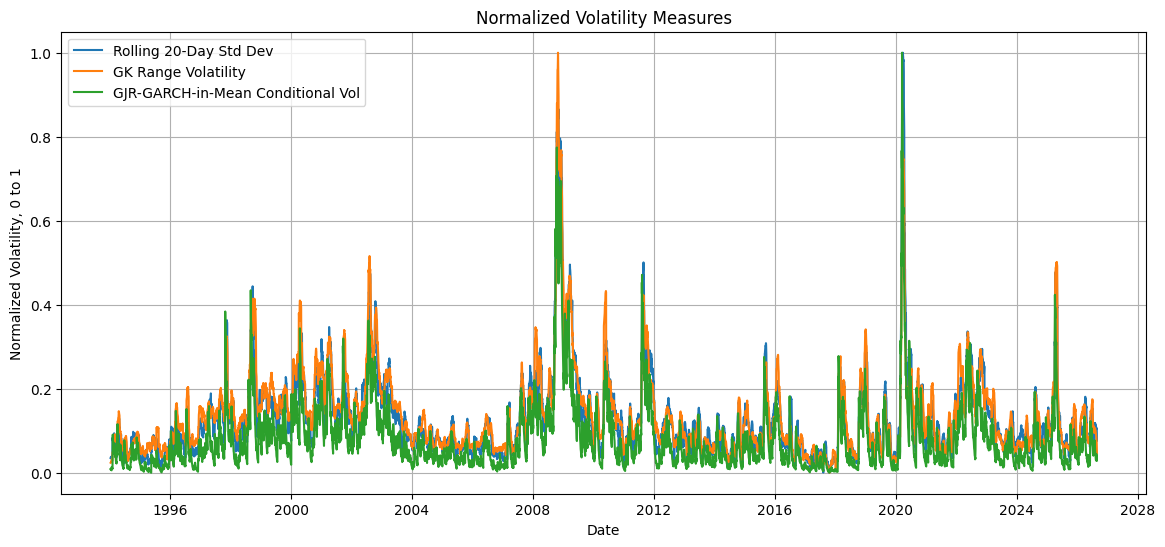

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# 1. Build volatility DataFrame
# -----------------------------
vol_df = pd.DataFrame(index=spx.index)

# Rolling 20-day standard deviation
vol_df['Rolling_20'] = spx['Return'].rolling(20).std()

# GK range volatility — convert array to Series with spx index
vol_df['GK_20'] = pd.Series(gk20, index=spx.index)

# GJR-GARCH conditional volatility — already has its own index
dates_garch = spx['Return'].dropna().index[nlags:]
cond_vol_series = pd.Series(
    garch_m_lev_results.conditional_volatility,
    index=dates_garch,
    name='GJR_GARCH_M'
)
vol_df['GJR_GARCH_M'] = cond_vol_series / 100

# -----------------------------
# 2. Align and trim
# -----------------------------
vol_df = vol_df.dropna()
vol_df = vol_df.iloc[1000:]

# -----------------------------
# 3. Normalize each column to [0, 1]
# -----------------------------
scaler = MinMaxScaler()
vol_norm = pd.DataFrame(
    scaler.fit_transform(vol_df),
    index=vol_df.index,
    columns=vol_df.columns
)

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(vol_norm.index, vol_norm['Rolling_20'],    label='Rolling 20-Day Std Dev',              linewidth=1.5)
plt.plot(vol_norm.index, vol_norm['GK_20'],         label='GK Range Volatility',                 linewidth=1.5)
plt.plot(vol_norm.index, vol_norm['GJR_GARCH_M'],   label='GJR-GARCH-in-Mean Conditional Vol',   linewidth=1.5)
plt.title('Normalized Volatility Measures')
plt.xlabel('Date')
plt.ylabel('Normalized Volatility, 0 to 1')
plt.legend()
plt.grid(True)
plt.savefig("volatility_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
# -----------------------------




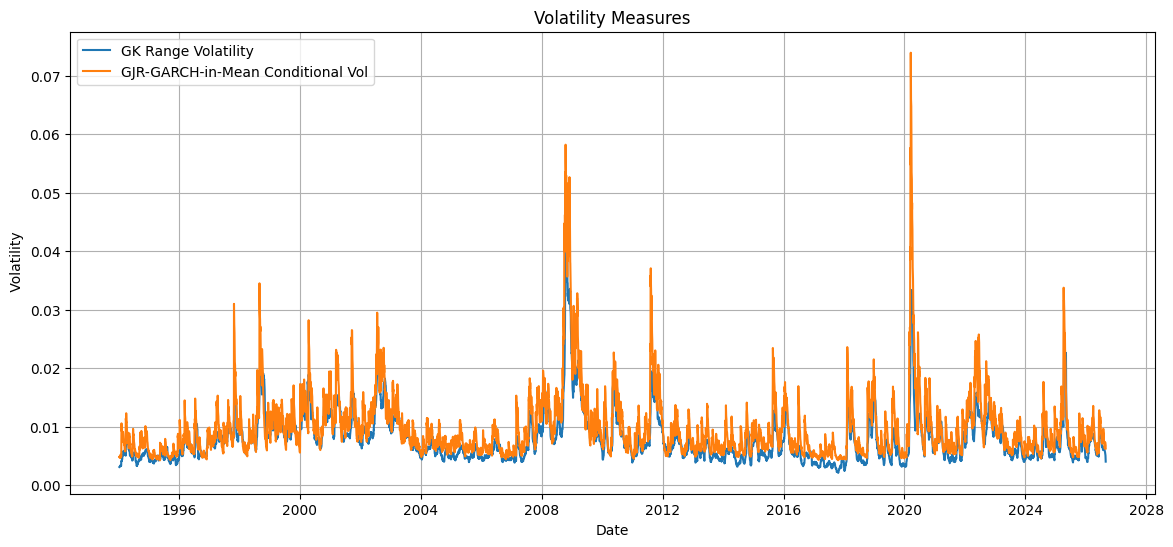

In [18]:
plt.figure(figsize=(14, 6))
#plt.plot(vol_norm.index, rolling_vol,    label='Rolling 20-Day Std Dev',              linewidth=3.5)
plt.plot(vol_norm.index, vol_df['GK_20'],         label='GK Range Volatility',                 linewidth=1.5)
plt.plot(vol_norm.index, vol_df['GJR_GARCH_M'],   label='GJR-GARCH-in-Mean Conditional Vol',   linewidth=1.5)
plt.title('Volatility Measures')
plt.xlabel('Date')
plt.ylabel(' Volatility')
plt.legend()
plt.grid(True)
plt.savefig("volatility_comparison.png", dpi=150, bbox_inches='tight')
plt.savefig("volatility_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
# -----------------------------

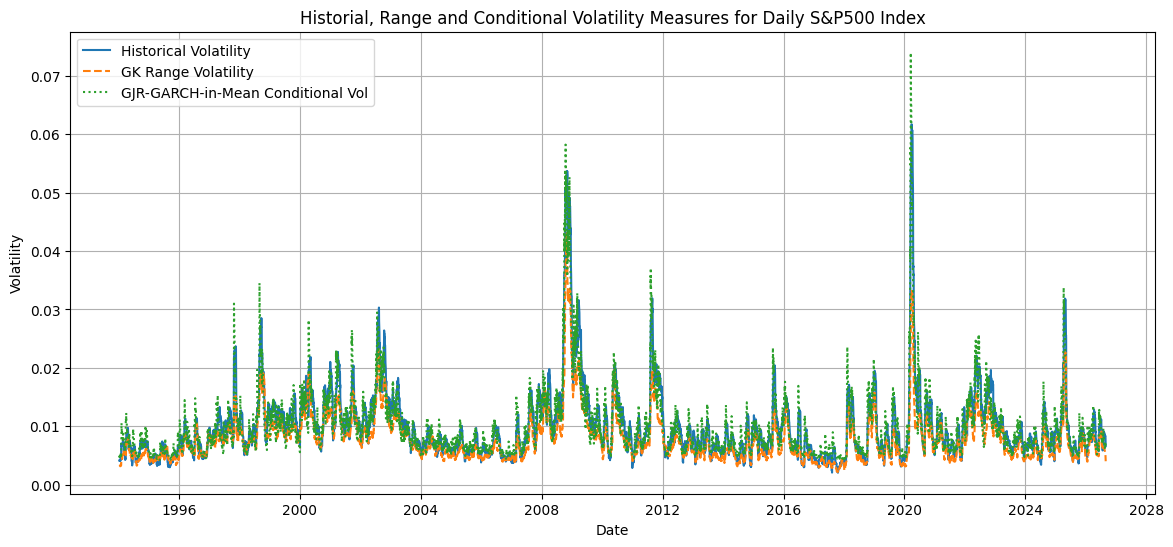

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(vol_df.index, vol_df['Rolling_20'],  
         label='Historical Volatility',            
         linewidth=1.5, linestyle='solid')
plt.plot(vol_df.index, vol_df['GK_20'],       
         label='GK Range Volatility',               
         linewidth=1.5, linestyle='dashed')
plt.plot(vol_df.index, vol_df['GJR_GARCH_M'], 
         label='GJR-GARCH-in-Mean Conditional Vol', 
         linewidth=1.5, linestyle='dotted')
plt.title('Historial, Range and Conditional Volatility Measures for Daily S&P500 Index')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.savefig("volatility_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of the GARCH Conditional Variance

* The figure shows the estimated **conditional variance** from the GARCH$(1,1)$ model:

$$
\sigma_t^2
=
\omega
+
\alpha \varepsilon_{t-1}^2
+
\beta \sigma_{t-1}^2.
$$

* The most important feature of the graph is **volatility clustering**. Periods of relatively low volatility tend to be followed by other low-volatility periods, while periods of high volatility tend to be followed by additional high-volatility periods.

* The large spikes correspond to periods of major financial and economic stress. Particularly noticeable episodes include the market turbulence around the early 2000s, the **Global Financial Crisis of 2008--2009**, and the exceptionally large increase in volatility during the **COVID-19 crisis in 2020**.

* After a major shock, conditional variance does not immediately return to its normal level. Instead, it declines gradually. This persistence is exactly what the GARCH model is designed to capture.

* In our estimated GARCH$(1,1)$ model,

$$
\hat{\alpha}=0.1054,
\qquad
\hat{\beta}=0.8776.
$$

Therefore,

$$
\hat{\alpha}+\hat{\beta}
=
0.1054+0.8776
=
0.9830.
$$

* Since this sum is very close to one, volatility is **highly persistent**. A large shock today raises predicted volatility not only today but also for a considerable period into the future.

* At the same time,

$$
\hat{\alpha}+\hat{\beta}<1,
$$

so the estimated GARCH process is mean reverting: following a volatility shock, conditional variance eventually moves back toward its long-run level.

* Thus, the figure illustrates an important empirical property of financial markets:

> **Returns themselves are difficult to predict, but the magnitude of return fluctuations is highly predictable and persistent.**

This is one of the principal motivations for using GARCH models in financial econometrics.


### Interpretation of the Volatility Episodes

* The three volatility measures move closely together and identify many of the same periods of financial-market stress. The GARCH measure tends to react especially strongly to large return shocks and then declines gradually because volatility is persistent.

* Several important episodes are visible in the figure:

  * **1997 -- Asian Financial Crisis:** Currency and financial crises that began in Thailand spread through several Asian economies and generated substantial uncertainty in international financial markets.

  * **1998 -- Russian Default and LTCM Crisis:** Russia defaulted on part of its government debt, and the hedge fund Long-Term Capital Management (LTCM) came close to collapse. Concerns about contagion and financial-system stability produced a sharp increase in U.S. market volatility.

  * **2000--2002 -- Dot-Com Collapse:** The rapid decline of technology stocks following the late-1990s technology boom produced an extended period of elevated volatility. This period also included the **September 11, 2001 terrorist attacks**, the 2001 recession, and major corporate accounting scandals such as Enron and WorldCom.

  * **2008--2009 -- Global Financial Crisis:** The collapse of the U.S. housing and mortgage markets, the failure of Lehman Brothers, and severe stress throughout the global banking system generated one of the largest volatility episodes in the sample.

  * **2010--2011 -- European Sovereign Debt Crisis:** Concerns about sovereign debt in Greece and other European countries, together with banking-system stress, raised uncertainty in global markets. In August 2011, the downgrade of U.S. sovereign debt by Standard & Poor's also contributed to a sharp increase in market volatility.

  * **2015--2016 -- China and Commodity-Market Turbulence:** Concerns about slowing Chinese growth, the August 2015 Chinese currency devaluation, and a major decline in oil and other commodity prices produced another period of heightened volatility.

  * **2018 -- Trade Tensions and Monetary Tightening:** Volatility increased sharply early in 2018 and again near the end of the year. Markets were affected by rising interest rates, tighter Federal Reserve policy, U.S.--China trade tensions, and concerns about slowing global growth.

  * **2020 -- COVID-19 Pandemic:** The onset of the pandemic and the sudden shutdown of economic activity produced the largest volatility spike in the figure.

  * **2022 -- Inflation, Ukraine, and Federal Reserve Tightening:** Inflation reached levels not experienced for several decades, Russia invaded Ukraine, energy prices rose sharply, and the Federal Reserve began an unusually rapid series of interest-rate increases. These developments produced another sustained period of elevated market volatility.

  * **2025 -- Tariff and Trade-Policy Uncertainty:** The particularly visible spike in 2025 coincides with the sharp market movements following the announcement of broad new U.S. tariffs in April 2025. Equity markets fell sharply as investors reassessed the implications of tariffs for inflation, economic growth, international trade, and Federal Reserve policy. Markets then rebounded dramatically when some of the tariffs were temporarily paused. The S&P 500 rose approximately $9.5%$ on April 9, illustrating how volatility can reflect unusually large movements in **both directions**.

* Thus, the volatility spikes are associated with very different types of shocks:

$$
\text{financial crises}
\quad+\quad
\text{geopolitical shocks}
\quad+\quad
\text{policy uncertainty}
\quad+\quad
\text{macroeconomic shocks}.
$$

* An important lesson is that **high volatility does not necessarily mean falling stock prices**. Volatility measures the magnitude of market movements rather than their direction. A period containing both large negative and large positive returns can therefore generate extremely high measured volatility.

* The figure also illustrates **volatility clustering**: after a large shock, volatility generally remains elevated for some time rather than immediately returning to its normal level. This is the central empirical feature that GARCH models are designed to capture.


## Comparing and Handicaping Models with AIC and BIC

* We can use the **Akaike Information Criterion (AIC)** and the **Bayesian Information Criterion (BIC)** to compare alternative volatility models such as GARCH and EGARCH.

* Both criteria balance two considerations:

  1. **Goodness of fit:** How well does the model explain the observed data?
  2. **Model complexity:** How many parameters were required to obtain that fit?

* A model with more parameters will generally be able to fit the sample data better. However, simply adding parameters does not necessarily produce a better model. AIC and BIC therefore impose a **penalty, or handicap, for additional parameters**.

### Akaike Information Criterion

The AIC is defined as

$$
\boxed{
AIC = -2\log L + 2k
}
$$

where

* $\log L$ is the maximized log-likelihood,
* $k$ is the number of estimated parameters.

The first term,

$$
-2\log L,
$$

rewards a model for fitting the data well. A higher log-likelihood produces a lower value of $-2\log L$.

The second term,

$$
2k,
$$

penalizes the model for using additional parameters.

Thus, adding another parameter is worthwhile only if the resulting improvement in the likelihood is large enough to compensate for the additional penalty.

### Bayesian Information Criterion

The BIC is defined as

$$
\boxed{
BIC = -2\log L + k\log T
}
$$

where $T$ is the number of observations.

Like the AIC, the BIC rewards better fit but penalizes additional parameters. However, the BIC penalty depends on the sample size:

$$
k\log T.
$$

For the large samples commonly used with daily financial data, this penalty can be substantially larger than the AIC penalty $2k$.

Therefore, **BIC generally favors more parsimonious models than AIC**.

### How Do We Choose the Model?

For both criteria, the rule is simple:

$$
\boxed{\text{Choose the model with the lower AIC or BIC.}}
$$

For example, suppose we obtain

| Model  |    AIC |    BIC |
| ------ | -----: | -----: |
| GARCH  | 24,486 | 24,550 |
| EGARCH | 24,420 | 24,500 |

Since the EGARCH model has both a lower AIC and a lower BIC, both criteria would select EGARCH.

The important comparison is the **difference** between the criteria rather than their absolute values. For the AIC, for example,

$$
\Delta AIC
=
AIC_{\text{GARCH}}
-
AIC_{\text{EGARCH}}.
$$

If $\Delta AIC>0$, the AIC favors EGARCH. If $\Delta AIC<0$, it favors GARCH.

### Why Might AIC and BIC Disagree?

AIC and BIC do not necessarily select the same model.

Suppose that EGARCH contains additional parameters that allow it to capture an asymmetric response of volatility to positive and negative shocks. Its likelihood may therefore be higher than that of the simpler GARCH model.

The question is whether the improvement in fit is large enough to justify the additional parameters.

AIC asks approximately:

$$
\text{Does the improvement in fit exceed the relatively small penalty for complexity?}
$$

BIC asks a more demanding question:

$$
\text{Does the improvement in fit exceed a larger penalty for complexity?}
$$

Consequently, we might find

$$
AIC_{\text{EGARCH}}
<
AIC_{\text{GARCH}},
$$

but

$$
BIC_{\text{GARCH}}
<
BIC_{\text{EGARCH}}.
$$

In this case, **AIC favors the more flexible EGARCH model, while BIC favors the simpler GARCH model**.

### Economic Interpretation

A useful way to think about AIC and BIC is that they impose a **handicap on complicated models**.

Adding parameters almost always makes it easier to fit the historical data. Without a penalty, we would tend to keep adding parameters and risk **overfitting**:

$$
\text{Better in-sample fit}
\quad \not\Rightarrow \quad
\text{better model}.
$$

AIC and BIC therefore evaluate

$$
\boxed{
\text{Model quality}
=
\text{fit}
-
\text{penalty for complexity}.
}
$$

The preferred model is the one that achieves the best balance between these two objectives.

### Application to GARCH and EGARCH

When comparing our GARCH and EGARCH estimates, ask:

1. Which model has the larger log-likelihood?
2. Which model has the lower AIC?
3. Which model has the lower BIC?
4. Do AIC and BIC select the same model?
5. If EGARCH is preferred, does the improved fit justify introducing an asymmetric response of volatility to positive and negative shocks?

The last question is particularly important economically. We should not choose a more complicated volatility model simply because it contains more parameters. The additional parameters should improve the model sufficiently to compensate for the greater complexity.
